# 01 — Exploratory Data Analysis

Explore the two core datasets used for next-day return prediction:
- **CRSP daily** — stock returns (target + momentum / volatility / size features)
- **Daily futures** — macro signals (lagged returns as features)

Key questions:
1. What is the date coverage and stock universe?
2. What does the return distribution look like (tails, skew)?
3. Which futures instruments have sufficient history?
4. Are there data quality issues (nulls, outliers, stale prices)?
5. What does a prototype of our features (momentum, vol) look like?

In [28]:
import sys, os
sys.path.insert(0, os.path.join('..'))   # project root on path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import wrds
import config
from src.data_loading import load_crsp, load_futures
from src.preprocessing import clean_crsp, clean_futures

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
pd.set_option('display.float_format', '{:.4f}'.format)
print('Config window:', config.START_DATE, '→', config.END_DATE)

Config window: 2000-01-01 → 2020-11-30


## 1  CRSP Daily Returns

In [29]:
# Loading the full file takes ~30 s
crsp_raw = load_crsp()
print(f'Raw shape : {crsp_raw.shape}')
print(f'Columns   : {list(crsp_raw.columns)}')
crsp_raw.head(3)

Raw shape : (47333141, 11)
Columns   : ['PERMNO', 'HdrCUSIP', 'CUSIP', 'Ticker', 'TradingSymbol', 'PERMCO', 'SICCD', 'NAICS', 'date', 'ret', 'mkt_ret']


,PERMNO,HdrCUSIP,CUSIP,Ticker,TradingSymbol,PERMCO,SICCD,NAICS,date,ret,mkt_ret
0,10001,36720410,29274A10,EWST,EWST,7953,4920,0,2000-01-03,0.0074,-0.0095
1,10001,36720410,29274A10,EWST,EWST,7953,4920,0,2000-01-04,-0.0146,-0.0383
2,10001,36720410,29274A10,EWST,EWST,7953,4920,0,2000-01-05,0.0148,0.0019


In [31]:
db = wrds.Connection(wrds_username="leowunderli")
# Fetch price and shares data for market cap calculations.
permno_list = ",".join(str(int(p)) for p in crsp_raw["PERMNO"].dropna().unique())
query = f"""
    SELECT permno, date, prc AS dlyprc, shrout
    FROM crsp.dsf
    WHERE date BETWEEN '{config.START_DATE}' AND '{config.END_DATE}'
      AND permno IN ({permno_list})
    """
wrds_df = db.raw_sql(query, date_cols=["date"])
wrds_df.rename(columns={"permno": "PERMNO", "dlyprc": "DlyPrc", "shrout": "ShrOut"}, inplace=True)

df = crsp_raw.merge(wrds_df, on=["PERMNO", "date"], how="left")
df["mktcap"] = df["DlyPrc"].abs() * df["ShrOut"] * 1_000
df["log_mktcap"] = np.log(df["mktcap"].clip(lower=1))

Loading library list...
Done


In [32]:
print('=== Raw CRSP ===')
print(f'Date range     : {crsp_raw["date"].min().date()} → {crsp_raw["date"].max().date()}')
print(f'Unique PERMNOs : {crsp_raw["PERMNO"].nunique():,}')
print(f'Total obs      : {len(crsp_raw):,}')

null_ret = crsp_raw['ret'].isna().sum()
print(f'\nMissing ret    : {null_ret:,}  ({null_ret/len(crsp_raw)*100:.2f}%)')

# Check if price / shares are present (needed for market cap)
mktcap_cols = {'mktcap', 'log_mktcap'} & set(df.columns)
print(f'\nMarket cap cols: {mktcap_cols or "NONE — re-download CRSP with DlyPrc + ShrOut from WRDS"}')

=== Raw CRSP ===
Date range     : 2000-01-03 → 2024-12-31
Unique PERMNOs : 23,660
Total obs      : 47,333,141

Missing ret    : 633,536  (1.34%)

Market cap cols: {'log_mktcap', 'mktcap'}


In [ ]:
crsp = clean_crsp(df)
dropped = len(crsp_raw) - len(crsp)
print(f'After cleaning : {len(crsp):,} obs, {crsp["PERMNO"].nunique():,} stocks')
print(f'Date range     : {crsp["date"].min().date()} → {crsp["date"].max().date()}')
print(f'Dropped        : {dropped:,} rows ({dropped/len(crsp_raw)*100:.1f}%)')


After cleaning : 37,206,893 obs, 19,075 stocks
Date range     : 2000-01-03 → 2020-11-30
Dropped        : 10,126,248 rows (21.4%)


### 1.1  Return distribution

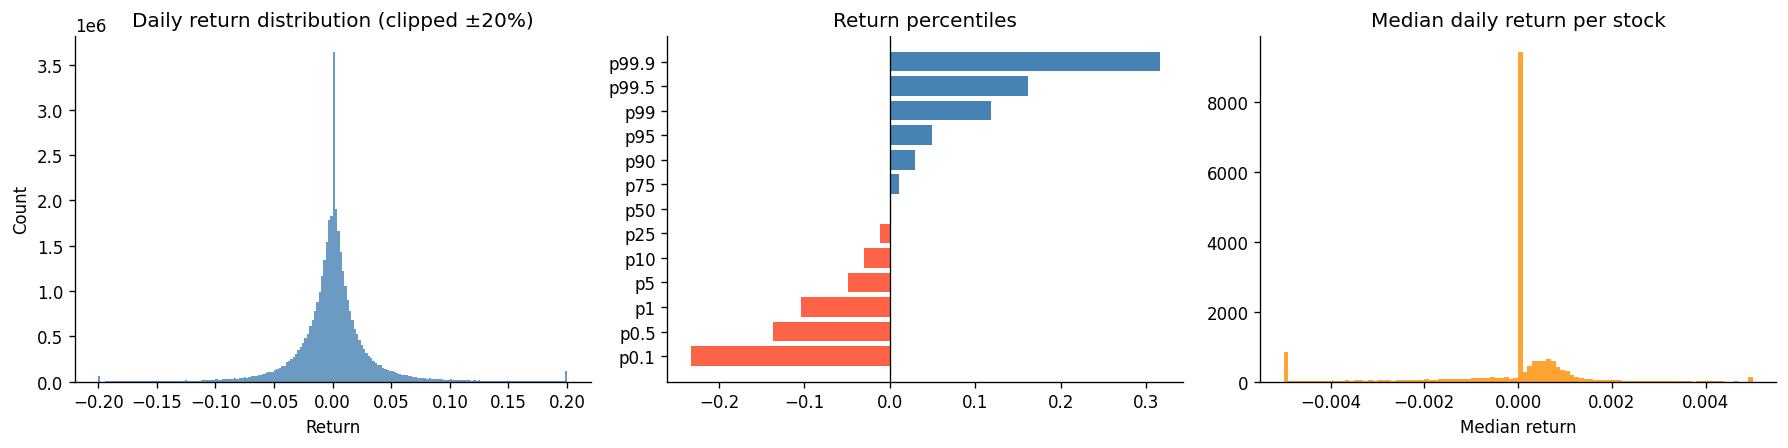

count   37206893.0000
mean           0.0005
std            0.0403
min           -1.0000
1%            -0.1045
5%            -0.0485
25%           -0.0112
50%            0.0000
75%            0.0109
95%            0.0493
99%            0.1182
max            3.0000
Name: ret, dtype: float64


In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram clipped for display
ret_clipped = crsp['ret'].clip(-0.20, 0.20)
axes[0].hist(ret_clipped, bins=200, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].set_title('Daily return distribution (clipped ±20%)')
axes[0].set_xlabel('Return')
axes[0].set_ylabel('Count')

# Tail percentiles
pcts = [0.1, 0.5, 1, 5, 10, 25, 50, 75, 90, 95, 99, 99.5, 99.9]
quantiles = np.percentile(crsp['ret'].dropna(), pcts)
axes[1].barh(range(len(pcts)), quantiles,
             color=['tomato' if q < 0 else 'steelblue' for q in quantiles])
axes[1].set_yticks(range(len(pcts)))
axes[1].set_yticklabels([f'p{p}' for p in pcts])
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('Return percentiles')

# Cross-sectional distribution of median returns per stock
med_by_stock = crsp.groupby('PERMNO')['ret'].median()
axes[2].hist(med_by_stock.clip(-0.005, 0.005), bins=100, color='darkorange', alpha=0.8)
axes[2].set_title('Median daily return per stock')
axes[2].set_xlabel('Median return')

plt.tight_layout()
os.makedirs(str(config.PLOTS_DIR), exist_ok=True)
plt.savefig(f'{config.PLOTS_DIR}/crsp_return_distribution.png', bbox_inches='tight')
plt.show()

print(crsp['ret'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))

### 1.2  Universe size over time

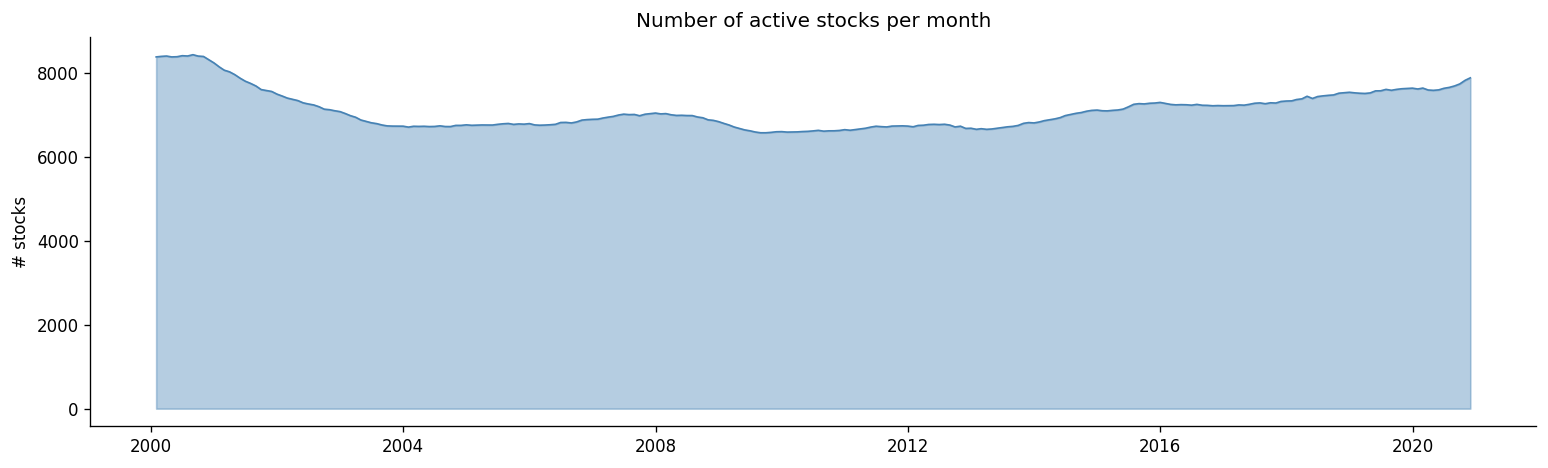

Min: 6,580   Max: 8,442   Median: 6,994


In [35]:
monthly_counts = (
    crsp.set_index('date')
    .resample('ME')['PERMNO']
    .nunique()
)

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(monthly_counts.index, monthly_counts.values, alpha=0.4, color='steelblue')
ax.plot(monthly_counts.index, monthly_counts.values, color='steelblue', lw=1)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_title('Number of active stocks per month')
ax.set_ylabel('# stocks')
plt.tight_layout()
plt.savefig(f'{config.PLOTS_DIR}/crsp_universe_size.png', bbox_inches='tight')
plt.show()

print(f'Min: {monthly_counts.min():,}   Max: {monthly_counts.max():,}   Median: {int(monthly_counts.median()):,}')

### 1.3  Cumulative market return vs equal-weighted average

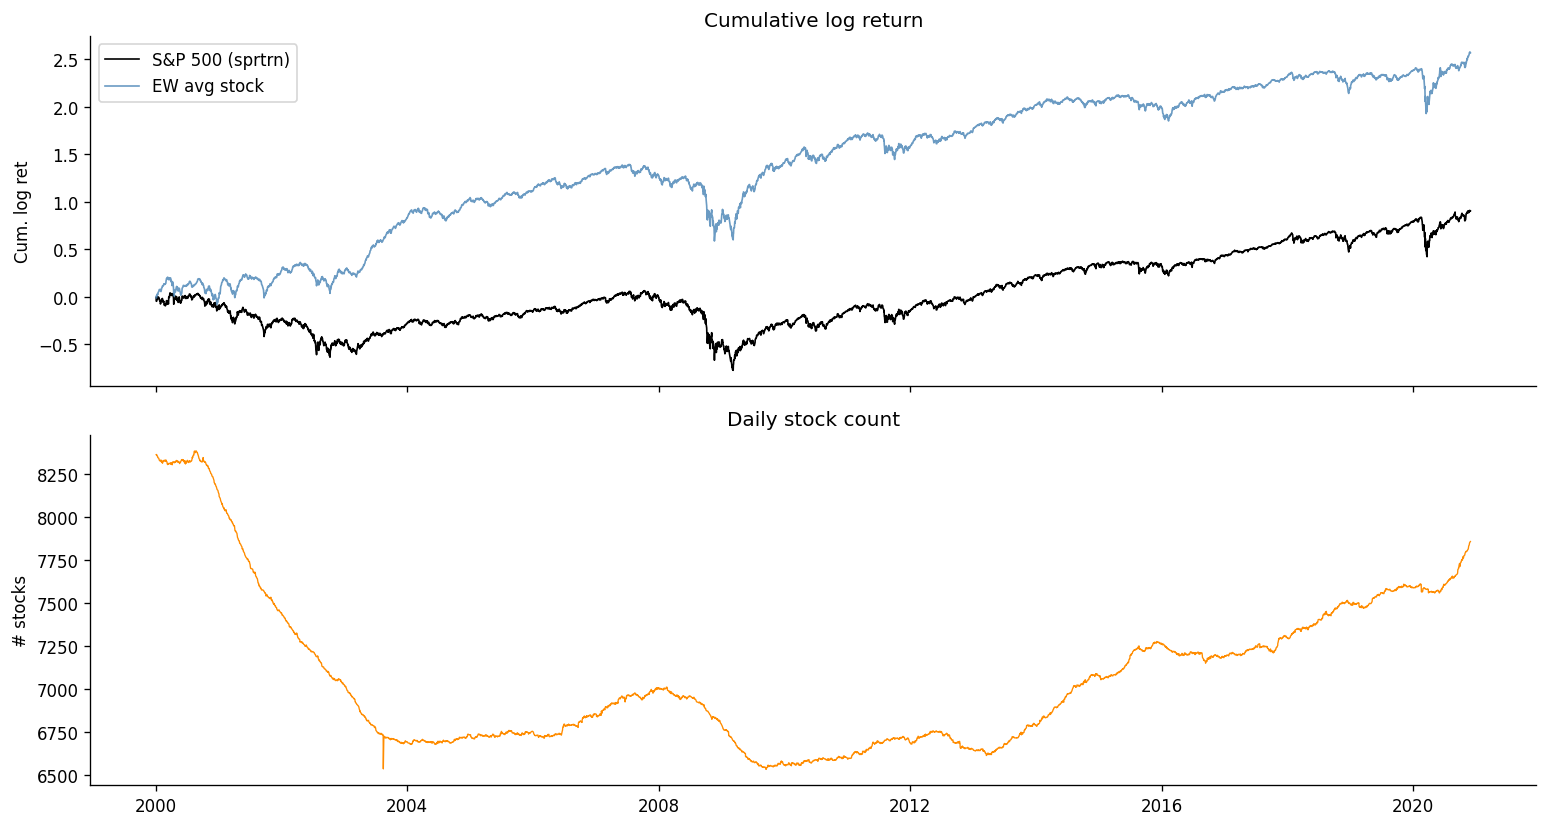

In [36]:
daily_agg = crsp.groupby('date').agg(
    ew_ret=('ret', 'mean'),
    mkt_ret=('mkt_ret', 'first'),
    n_stocks=('PERMNO', 'nunique'),
).reset_index()

daily_agg['cum_ew']  = np.log1p(daily_agg['ew_ret']).cumsum()
daily_agg['cum_mkt'] = np.log1p(daily_agg['mkt_ret']).cumsum()

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(daily_agg['date'], daily_agg['cum_mkt'], label='S&P 500 (sprtrn)', color='black', lw=1)
axes[0].plot(daily_agg['date'], daily_agg['cum_ew'],  label='EW avg stock',     color='steelblue', lw=1, alpha=0.8)
axes[0].set_title('Cumulative log return')
axes[0].legend()
axes[0].set_ylabel('Cum. log ret')

axes[1].plot(daily_agg['date'], daily_agg['n_stocks'], color='darkorange', lw=0.8)
axes[1].set_title('Daily stock count')
axes[1].set_ylabel('# stocks')

plt.tight_layout()
plt.savefig(f'{config.PLOTS_DIR}/crsp_cumulative_returns.png', bbox_inches='tight')
plt.show()

### 1.4  Observations per stock (coverage)

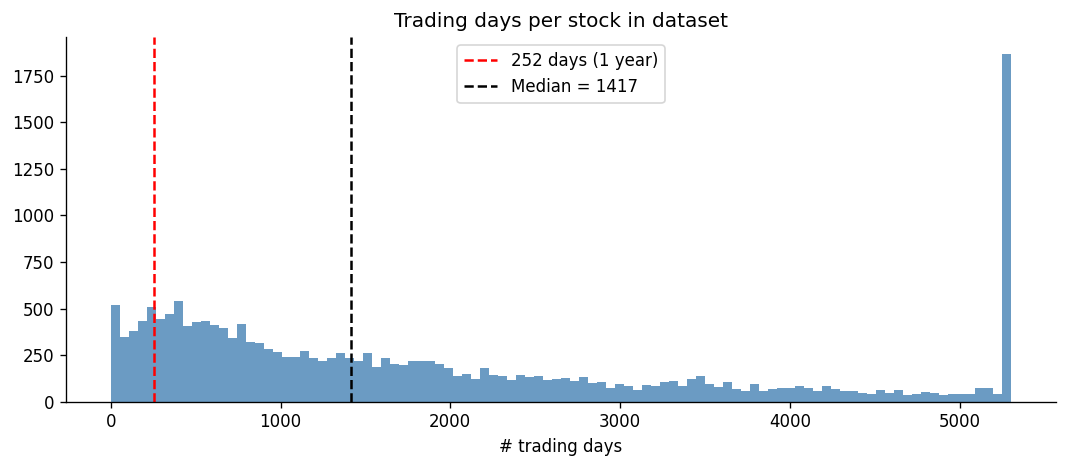

count   19075.0000
mean     1950.5580
std      1667.2313
min         1.0000
10%       238.0000
25%       566.0000
50%      1417.0000
75%      3025.5000
90%      5194.0000
max      5303.0000
dtype: float64

Stocks with <252 days (< 1y): 2,046 (10.7%)


In [37]:
obs_per_stock = crsp.groupby('PERMNO').size()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(obs_per_stock, bins=100, color='steelblue', alpha=0.8)
ax.axvline(252, color='red', lw=1.5, ls='--', label='252 days (1 year)')
ax.axvline(obs_per_stock.median(), color='black', lw=1.5, ls='--',
           label=f'Median = {int(obs_per_stock.median())}')
ax.set_title('Trading days per stock in dataset')
ax.set_xlabel('# trading days')
ax.legend()
plt.tight_layout()
plt.show()

print(obs_per_stock.describe(percentiles=[.1, .25, .5, .75, .9]))
print(f'\nStocks with <252 days (< 1y): {(obs_per_stock < 252).sum():,} ({(obs_per_stock < 252).mean()*100:.1f}%)')

### 1.5  Market cap — WRDS download required

> **Action**: Re-download CRSP from WRDS and add `DlyPrc` (closing price) and `ShrOut` (shares outstanding in thousands).  
> `preprocessing.clean_crsp()` will then compute `log_mktcap = log(|DlyPrc| × ShrOut × 1000)` automatically.

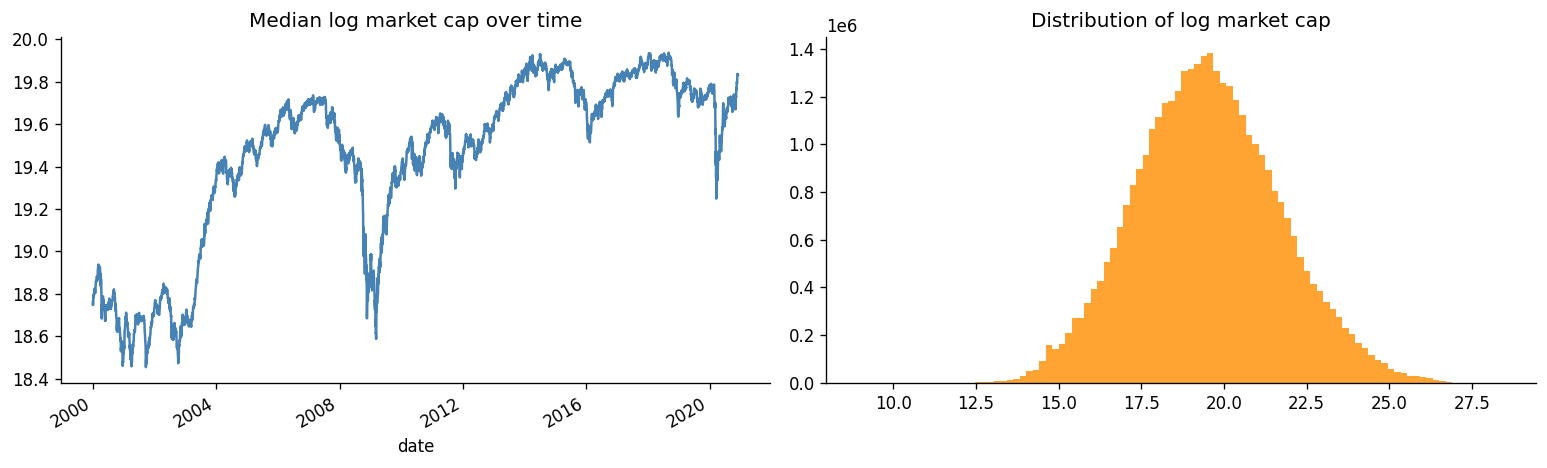

count   37195358.0000
mean          19.5027
std            2.1696
min            8.9554
25%           18.0050
50%           19.4469
75%           20.9439
max           28.4617
Name: log_mktcap, dtype: Float64


In [38]:
if 'log_mktcap' in crsp.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    crsp.groupby('date')['log_mktcap'].median().plot(ax=axes[0], color='steelblue')
    axes[0].set_title('Median log market cap over time')
    axes[1].hist(crsp['log_mktcap'].dropna(), bins=100, color='darkorange', alpha=0.8)
    axes[1].set_title('Distribution of log market cap')
    plt.tight_layout(); plt.show()
    print(crsp['log_mktcap'].describe())
else:
    print('log_mktcap not yet available — add DlyPrc + ShrOut to the CRSP download.')

---
## 2  Daily Futures

In [39]:
futures_raw = load_futures()
print(f'Shape      : {futures_raw.shape}')
print(f'Date range : {futures_raw["date"].min().date()} → {futures_raw["date"].max().date()}')
print(f'Instruments: {futures_raw.shape[1] - 1}')
futures_raw.head(3)

Shape      : (15725, 80)
Date range : 1959-07-01 → 2020-11-06
Instruments: 79


,date,CBOE_VX,CME_AD,CME_BO,CME_BP,CME_C,CME_CD,CME_CL,CME_DA,CME_EC,...,LIFFE_R,LIFFE_Z,MGEX_MW,MX_SXF,SHFE_AL,SHFE_CU,SHFE_PB,SHFE_RB,SHFE_RU,SHFE_ZN
0,1959-07-01,NaN,NaN,NaN,NaN,5713.4076,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1959-07-02,NaN,NaN,NaN,NaN,5708.5534,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1959-07-06,NaN,NaN,NaN,NaN,5684.2823,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2.1  Coverage per instrument

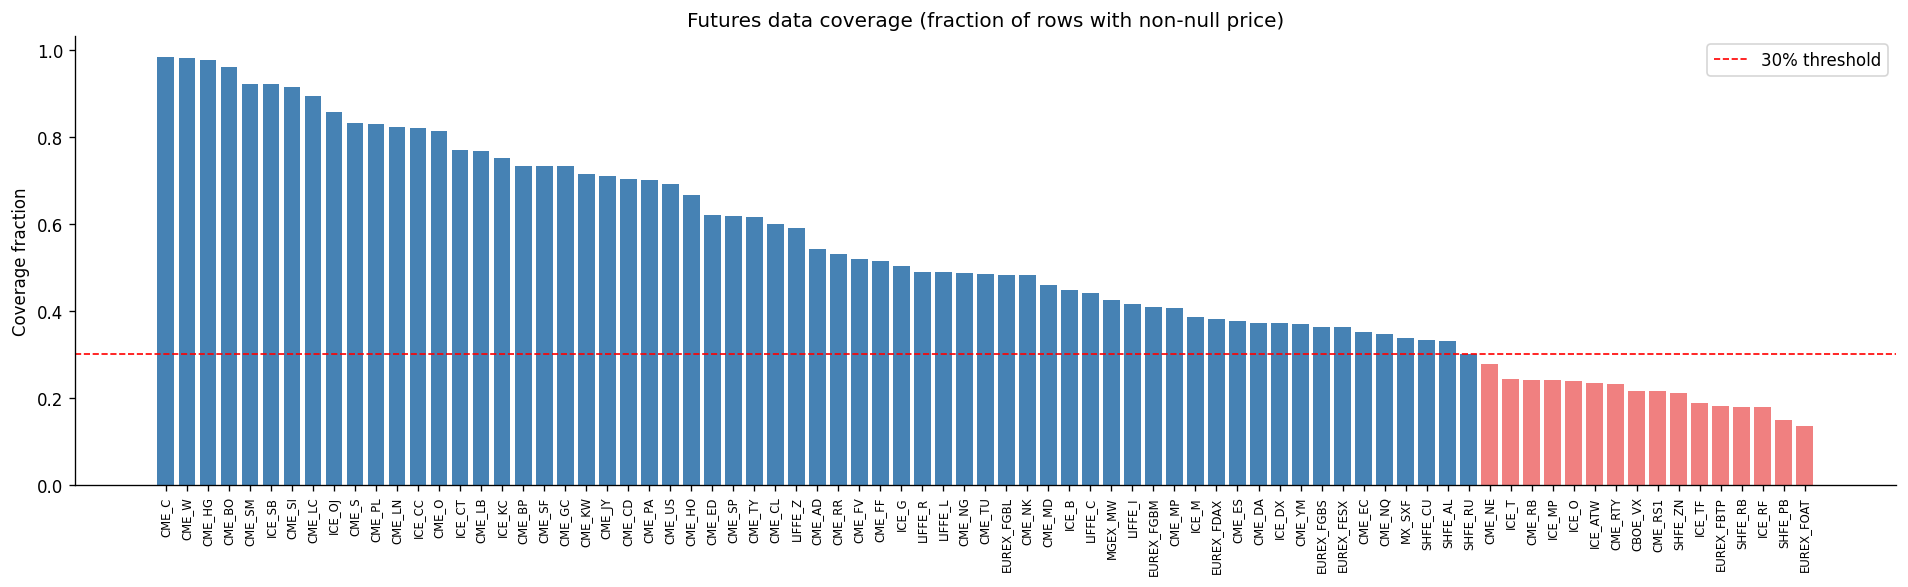

Instruments >30% coverage: 63
Instruments >50% coverage: 36
Instruments >80% coverage: 14


In [40]:
price_cols = [c for c in futures_raw.columns if c != 'date']
coverage = futures_raw[price_cols].notna().mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(16, 5))
colors = ['steelblue' if v >= 0.3 else 'lightcoral' for v in coverage]
ax.bar(range(len(coverage)), coverage.values, color=colors)
ax.axhline(0.3, color='red', ls='--', lw=1, label='30% threshold')
ax.set_xticks(range(len(coverage)))
ax.set_xticklabels(coverage.index, rotation=90, fontsize=7)
ax.set_title('Futures data coverage (fraction of rows with non-null price)')
ax.set_ylabel('Coverage fraction')
ax.legend()
plt.tight_layout()
plt.savefig(f'{config.PLOTS_DIR}/futures_coverage.png', bbox_inches='tight')
plt.show()

print(f'Instruments >30% coverage: {(coverage >= 0.3).sum()}')
print(f'Instruments >50% coverage: {(coverage >= 0.5).sum()}')
print(f'Instruments >80% coverage: {(coverage >= 0.8).sum()}')

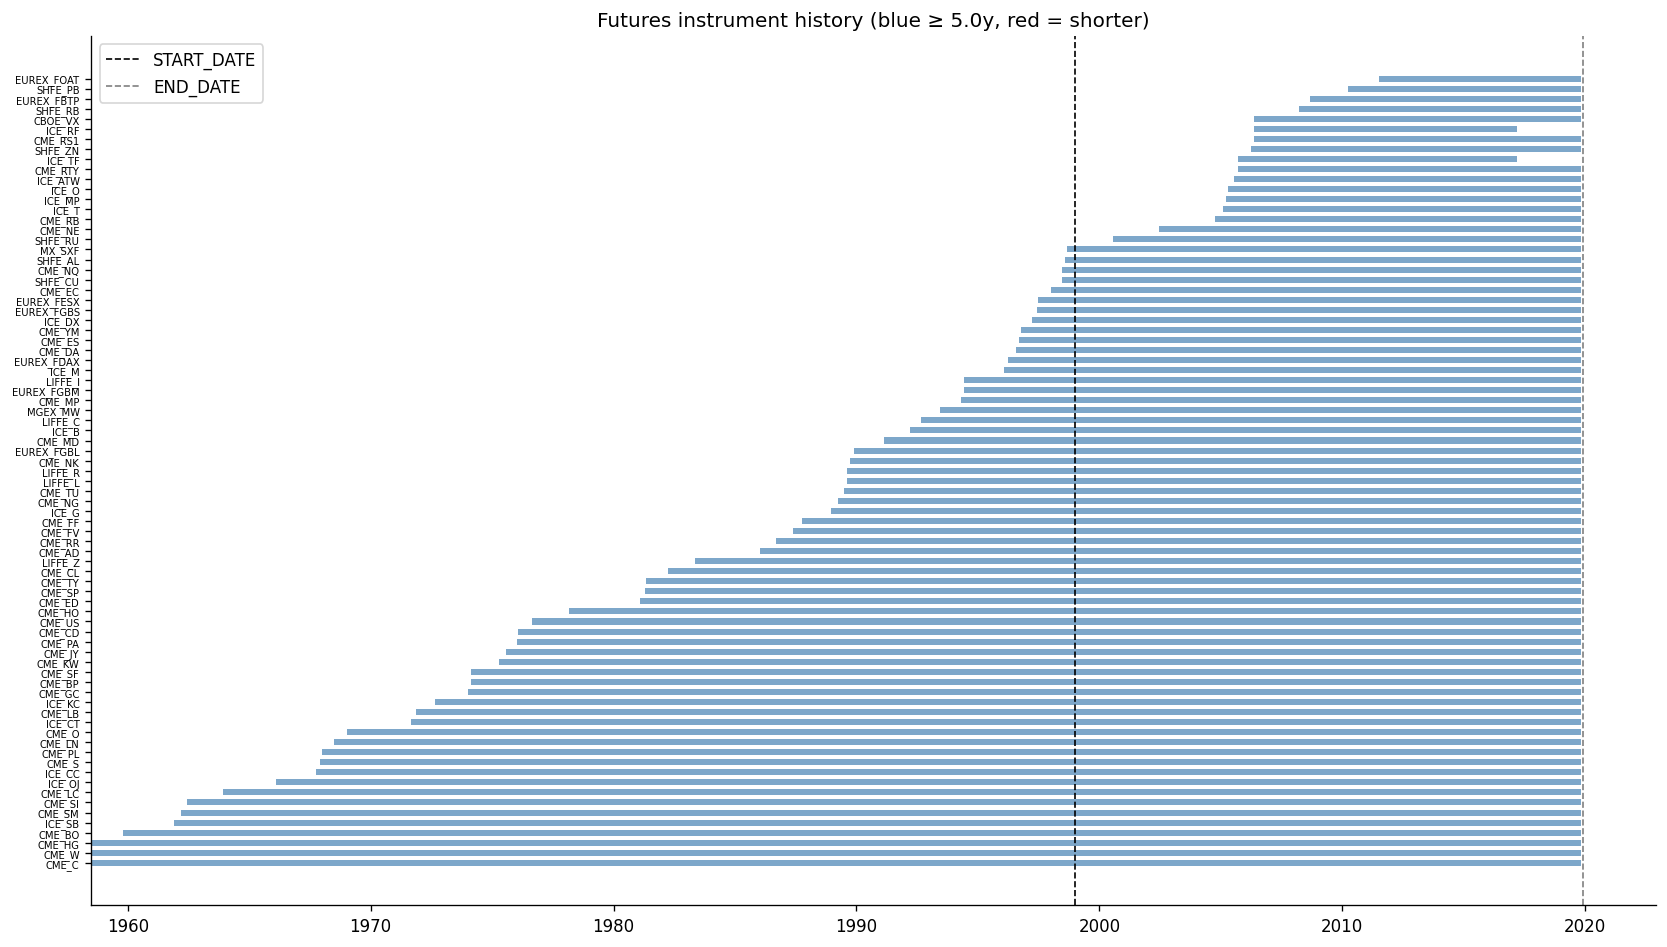

In [41]:
# Instrument lifespan chart
first_date = futures_raw.set_index('date')[price_cols].apply(lambda s: s.first_valid_index())
last_date  = futures_raw.set_index('date')[price_cols].apply(lambda s: s.last_valid_index())
span_df = pd.DataFrame({'first': first_date, 'last': last_date})
span_df['years'] = (span_df['last'] - span_df['first']).dt.days / 365
span_df = span_df.sort_values('first')

fig, ax = plt.subplots(figsize=(14, 8))
for i, (inst, row) in enumerate(span_df.iterrows()):
    color = 'steelblue' if row['years'] >= config.FUTURES_MIN_HISTORY_YEARS else 'lightcoral'
    ax.barh(i, (row['last'] - row['first']).days,
            left=row['first'].toordinal(), height=0.6, color=color, alpha=0.7)

year_ticks = pd.date_range('1960', '2025', freq='10YE')
ax.set_xticks([d.toordinal() for d in year_ticks])
ax.set_xticklabels([d.year for d in year_ticks])
ax.set_yticks(range(len(span_df)))
ax.set_yticklabels(span_df.index, fontsize=6)
ax.set_title(f'Futures instrument history (blue ≥ {config.FUTURES_MIN_HISTORY_YEARS}y, red = shorter)')
ax.axvline(pd.Timestamp(config.START_DATE).toordinal(), color='black', ls='--', lw=1, label='START_DATE')
ax.axvline(pd.Timestamp(config.END_DATE).toordinal(),   color='grey',  ls='--', lw=1, label='END_DATE')
ax.legend()
plt.tight_layout()
plt.savefig(f'{config.PLOTS_DIR}/futures_instrument_span.png', bbox_inches='tight')
plt.show()

### 2.2  Clean futures & compute log returns

In [42]:
futures = clean_futures(futures_raw, min_history_years=config.FUTURES_MIN_HISTORY_YEARS)
fut_cols = [c for c in futures.columns if c != 'date']
print(f'Kept {len(fut_cols)} instruments after history filter')
print(f'Date range : {futures["date"].min().date()} → {futures["date"].max().date()}')
print(f'Shape      : {futures.shape}')

Futures: kept 79/79 instruments (≥5.0y of data in 2000-01-01–2020-11-30)
Kept 79 instruments after history filter
Date range : 2000-01-03 → 2020-11-06
Shape      : (5427, 80)


### 2.3  Volatility and pairwise correlation

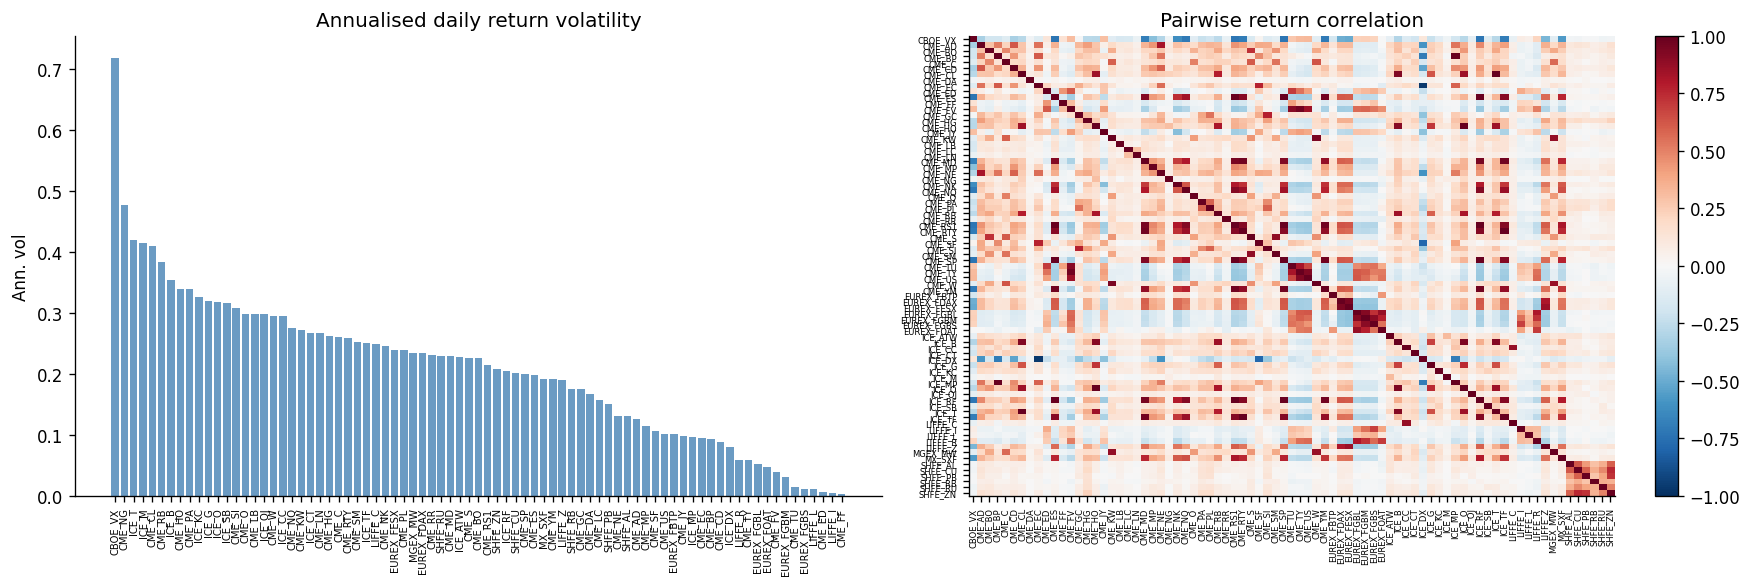

In [43]:
fut_rets = futures[fut_cols]
annualised_vol = (fut_rets.std() * np.sqrt(252)).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(range(len(annualised_vol)), annualised_vol.values, color='steelblue', alpha=0.8)
axes[0].set_xticks(range(len(annualised_vol)))
axes[0].set_xticklabels(annualised_vol.index, rotation=90, fontsize=6)
axes[0].set_title('Annualised daily return volatility')
axes[0].set_ylabel('Ann. vol')

corr = fut_rets.corr(min_periods=252)
im = axes[1].imshow(corr.fillna(0), cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axes[1].set_title('Pairwise return correlation')
axes[1].set_xticks(range(len(fut_cols)))
axes[1].set_yticks(range(len(fut_cols)))
axes[1].set_xticklabels(fut_cols, rotation=90, fontsize=5)
axes[1].set_yticklabels(fut_cols, fontsize=5)
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.savefig(f'{config.PLOTS_DIR}/futures_vol_and_corr.png', bbox_inches='tight')
plt.show()

In [44]:
# Date overlap between CRSP and futures
crsp_dates = set(crsp['date'])
fut_dates  = set(futures['date'])
overlap    = crsp_dates & fut_dates
print(f'CRSP trading days   : {len(crsp_dates):,}')
print(f'Futures trading days: {len(fut_dates):,}')
print(f'Overlap             : {len(overlap):,}')

CRSP trading days   : 5,262
Futures trading days: 5,427
Overlap             : 5,247


---
## 3  Feature Prototype

Compute momentum and volatility on a small subset to verify the logic before running on the full 47M-row panel.

In [45]:
from src.feature_engineering import add_momentum, add_reversal, add_volatility, add_target

# 20 stocks with the longest history in the cleaned dataset
top_stocks = crsp.groupby('PERMNO').size().nlargest(20).index
sample = crsp[crsp['PERMNO'].isin(top_stocks)].copy()

sample = add_momentum(sample)
sample = add_reversal(sample)
sample = add_volatility(sample)
sample = add_target(sample)

mom_cols = [f'mom_{w}d' for w in config.MOMENTUM_WINDOWS]
vol_cols = [f'vol_{w}d' for w in config.VOLATILITY_WINDOWS]

print('Feature NaN rates (should only be non-zero for the warm-up period):')
for c in ['reversal_1d'] + mom_cols + vol_cols + ['target']:
    print(f'  {c:20s}: {sample[c].isna().mean():.3f}')

Feature NaN rates (should only be non-zero for the warm-up period):
  reversal_1d         : 0.000
  mom_5d              : 0.001
  mom_21d             : 0.002
  mom_63d             : 0.006
  mom_126d            : 0.012
  mom_252d            : 0.024
  vol_21d             : 0.002
  vol_63d             : 0.006
  vol_252d            : 0.024
  target              : 0.000


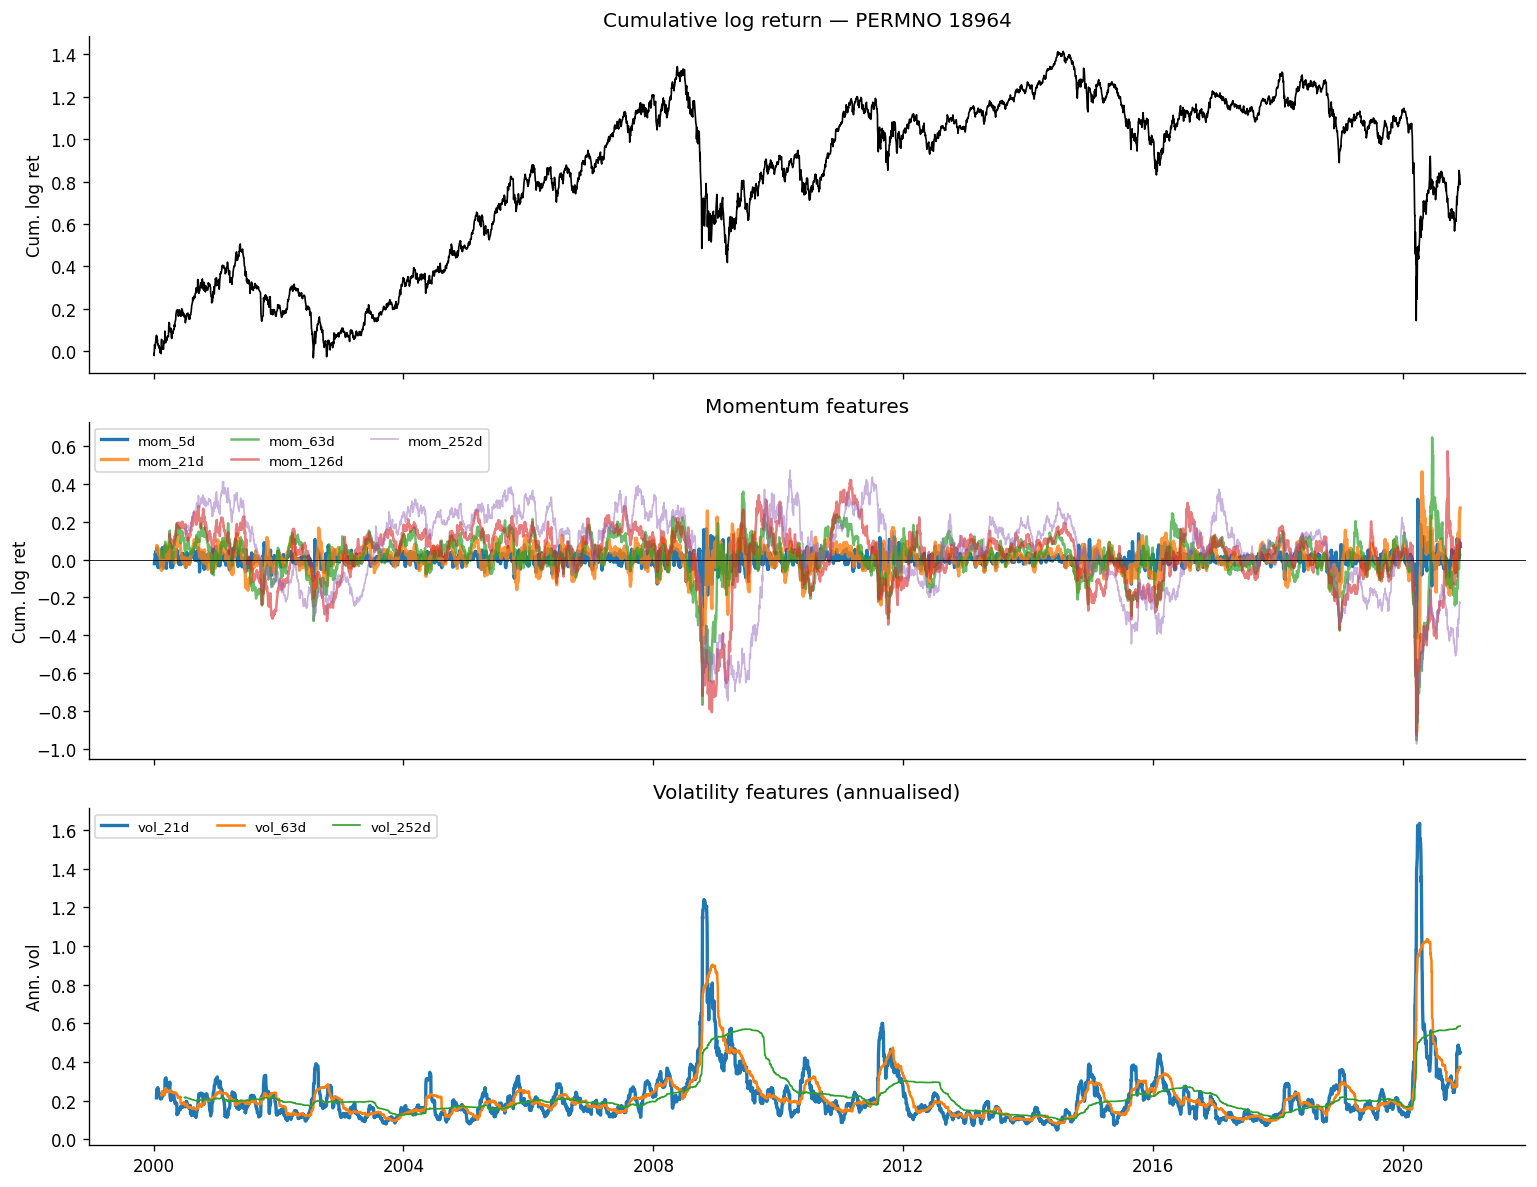

In [46]:
# Visualise features for one stock
permno = top_stocks[0]
stock  = sample[sample['PERMNO'] == permno].set_index('date')

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

axes[0].plot(stock.index, np.log1p(stock['ret']).cumsum(), color='black', lw=1)
axes[0].set_title(f'Cumulative log return — PERMNO {permno}')
axes[0].set_ylabel('Cum. log ret')

for col, lw, alpha in zip(mom_cols, [2, 2, 1.5, 1.5, 1], [1, 0.8, 0.7, 0.6, 0.5]):
    axes[1].plot(stock.index, stock[col], label=col, lw=lw, alpha=alpha)
axes[1].axhline(0, color='black', lw=0.5)
axes[1].set_title('Momentum features')
axes[1].set_ylabel('Cum. log ret')
axes[1].legend(ncol=3, fontsize=8)

for col, lw in zip(vol_cols, [2, 1.5, 1]):
    axes[2].plot(stock.index, stock[col], label=col, lw=lw)
axes[2].set_title('Volatility features (annualised)')
axes[2].set_ylabel('Ann. vol')
axes[2].legend(ncol=3, fontsize=8)

plt.tight_layout()
plt.savefig(f'{config.PLOTS_DIR}/feature_prototype_single_stock.png', bbox_inches='tight')
plt.show()

In [47]:
# Rank IC: spearman correlation of each feature with next-day return
feature_cols = ['reversal_1d'] + mom_cols + vol_cols

ic_by_date = (
    sample.dropna(subset=feature_cols + ['target'])
    .groupby('date')
    .apply(lambda g: g[feature_cols + ['target']]
           .corr(method='spearman')['target']
           .drop('target'),
           include_groups=False)
)

mean_ic = ic_by_date.mean()
t_stat  = ic_by_date.mean() / (ic_by_date.std() / np.sqrt(len(ic_by_date)))

ic_summary = pd.DataFrame({'Mean IC': mean_ic, 't-stat': t_stat})
print('Rank IC (feature vs next-day return) — 20-stock sample:')
print(ic_summary.to_string())

Rank IC (feature vs next-day return) — 20-stock sample:
             Mean IC  t-stat
target                      
reversal_1d  -0.0074 -1.8421
mom_5d       -0.0120 -2.9700
mom_21d       0.0027  0.6735
mom_63d       0.0013  0.3304
mom_126d      0.0085  2.1133
mom_252d      0.0103  2.5939
vol_21d       0.0019  0.4628
vol_63d       0.0044  1.0681
vol_252d      0.0031  0.7587


---
## 4  Dataset Alignment Summary

In [48]:
crsp_window = crsp[(crsp['date'] >= config.START_DATE) & (crsp['date'] <= config.END_DATE)]
fut_window  = futures[(futures['date'] >= config.START_DATE) & (futures['date'] <= config.END_DATE)]

n_stock_features   = 1 + len(config.MOMENTUM_WINDOWS) + len(config.VOLATILITY_WINDOWS)
n_futures_features = len(fut_cols) * len(config.FUTURES_LAGS)
total_features     = n_stock_features + 1 + n_futures_features   # +1 for size (pending)

print('=== Dataset alignment in project window ===')
print(f'CRSP rows             : {len(crsp_window):>12,}')
print(f'CRSP unique stocks    : {crsp_window["PERMNO"].nunique():>12,}')
print(f'CRSP trading days     : {crsp_window["date"].nunique():>12,}')
print()
print(f'Futures rows          : {len(fut_window):>12,}')
print(f'Futures instruments   : {len(fut_cols):>12,}')
print(f'Futures trading days  : {fut_window["date"].nunique():>12,}')
print()
print(f'Expected feature count: {total_features}')
print(f'  reversal            :  1')
print(f'  momentum            :  {len(config.MOMENTUM_WINDOWS)}  ({config.MOMENTUM_WINDOWS})')
print(f'  volatility          :  {len(config.VOLATILITY_WINDOWS)}  ({config.VOLATILITY_WINDOWS})')
print(f'  size (log mktcap)   :  1  (pending WRDS download)')
print(f'  futures macro       :  {n_futures_features}  ({len(fut_cols)} instruments × {len(config.FUTURES_LAGS)} lags)')

=== Dataset alignment in project window ===
CRSP rows             :   37,206,893
CRSP unique stocks    :       19,075
CRSP trading days     :        5,262

Futures rows          :        5,427
Futures instruments   :           79
Futures trading days  :        5,427

Expected feature count: 326
  reversal            :  1
  momentum            :  5  ([5, 21, 63, 126, 252])
  volatility          :  3  ([21, 63, 252])
  size (log mktcap)   :  1  (pending WRDS download)
  futures macro       :  316  (79 instruments × 4 lags)


---
## 5  Action items before `02_features.ipynb`

| # | Task | Status |
|---|------|--------|
| 2 | Decide minimum stock history threshold (e.g. ≥252 days) | ⬜ |
| 3 | Decide whether to exclude micro-caps (size filter) | ⬜ |
| 4 | Confirm train / val / test split (`config.py`: 2000–2015 / 2016–2018 / 2019–2020) | ⬜ |